In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay
from sklearn.cluster import KMeans

In [37]:
#Load dataset
global_finance = pd.read_csv('../working/Global finance data.csv')
global_finance.head()

,Country,Date,Stock_Index,Index_Value,Daily_Change_Percent,Market_Cap_Trillion_USD,GDP_Growth_Rate_Percent,Inflation_Rate_Percent,Interest_Rate_Percent,Unemployment_Rate_Percent,...,Commodity_Index,Oil_Price_USD_Barrel,Gold_Price_USD_Ounce,Bond_Yield_10Y_Percent,Credit_Rating,Political_Risk_Score,Banking_Sector_Health,Real_Estate_Index,Export_Growth_Percent,Import_Growth_Percent
0,United States,2024-08-15,S&P_500,5437.2,0.34,51.2,2.8,2.9,5.50,3.7,...,1.12,77.85,2487.5,4.25,AAA,8.1,Strong,145.6,3.2,2.8
1,China,2024-08-15,Shanghai_Composite,2891.6,-0.82,12.4,5.2,0.8,3.10,5.2,...,0.98,77.85,2487.5,2.15,A+,6.7,Moderate,98.7,8.9,6.1
2,Japan,2024-08-15,Nikkei_225,36789.1,1.24,6.8,0.9,2.8,-0.10,2.4,...,1.05,77.85,2487.5,0.89,A+,8.4,Strong,89.3,5.1,4.7
3,Germany,2024-08-15,DAX,18234.5,0.67,2.9,0.3,2.2,4.50,3.1,...,1.08,77.85,2487.5,2.31,AAA,8.7,Strong,112.4,2.1,1.8
4,United Kingdom,2024-08-15,FTSE_100,8156.3,-0.15,3.1,1.1,2.0,5.25,4.2,...,1.06,77.85,2487.5,3.89,AA,7.9,Moderate,97.8,0.9,1.2


In [49]:
# Check the first few rows
print(global_finance.head())

# Check column types
print(global_finance.info())

# Check for missing values
print(global_finance.isnull().sum())

# Summary statistics
print(global_finance.describe())

          Country       Date         Stock_Index  Index_Value  \
0   United States 2024-08-15             S&P_500       5437.2   
1           China 2024-08-15  Shanghai_Composite       2891.6   
2           Japan 2024-08-15          Nikkei_225      36789.1   
3         Germany 2024-08-15                 DAX      18234.5   
4  United Kingdom 2024-08-15            FTSE_100       8156.3   

   Daily_Change_Percent  Market_Cap_Trillion_USD  GDP_Growth_Rate_Percent  \
0                  0.34                     51.2                      2.8   
1                 -0.82                     12.4                      5.2   
2                  1.24                      6.8                      0.9   
3                  0.67                      2.9                      0.3   
4                 -0.15                      3.1                      1.1   

   Inflation_Rate_Percent  Interest_Rate_Percent  Unemployment_Rate_Percent  \
0                     2.9                   5.50                   

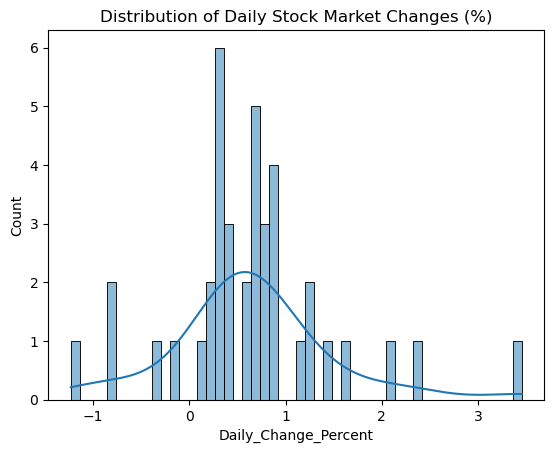

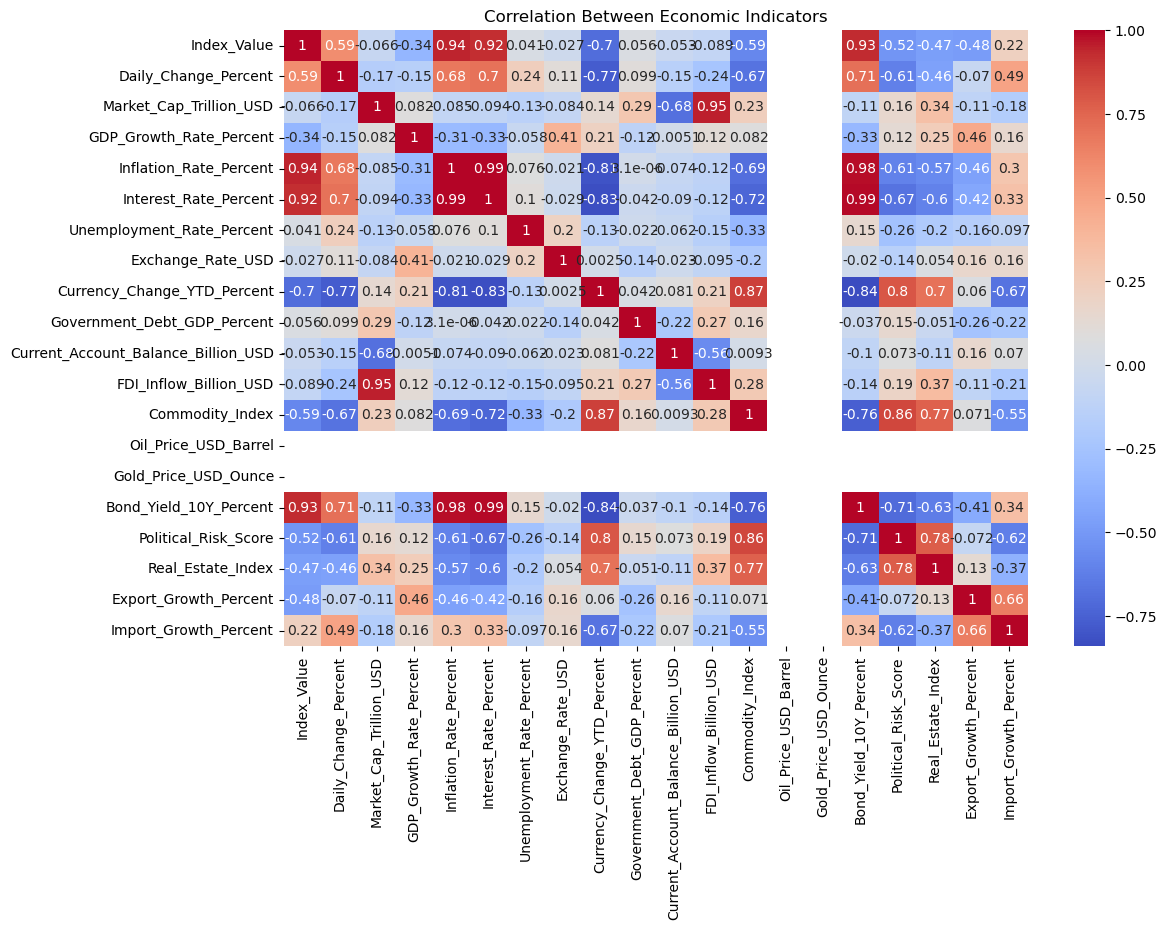

In [38]:
# Convert Date to datetime to allow time series analysis 

# Distribution of stock index daily changes
sns.histplot(global_finance['Daily_Change_Percent'], bins=50, kde=True)
plt.title("Distribution of Daily Stock Market Changes (%)")
plt.show()

# Correlation heatmap of numeric columns
numeric_cols = global_finance.select_dtypes(include='number')
plt.figure(figsize=(12,8))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Between Economic Indicators")
plt.show()
global_finance['Date'] = pd.to_datetime(global_finance['Date'])

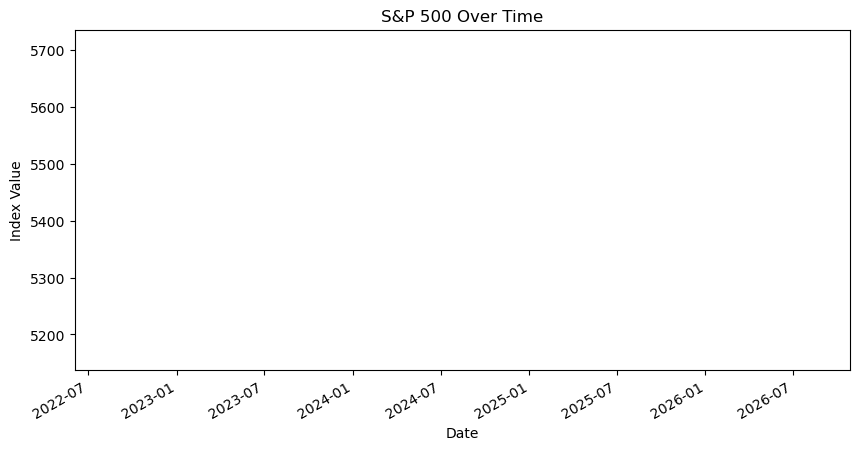

In [40]:
# Country specific trends
df_us = global_finance[global_finance['Country'] == 'United States']
df_us.set_index('Date')['Index_Value'].plot(figsize=(10,5), title='S&P 500 Over Time')
plt.ylabel('Index Value')
plt.show()

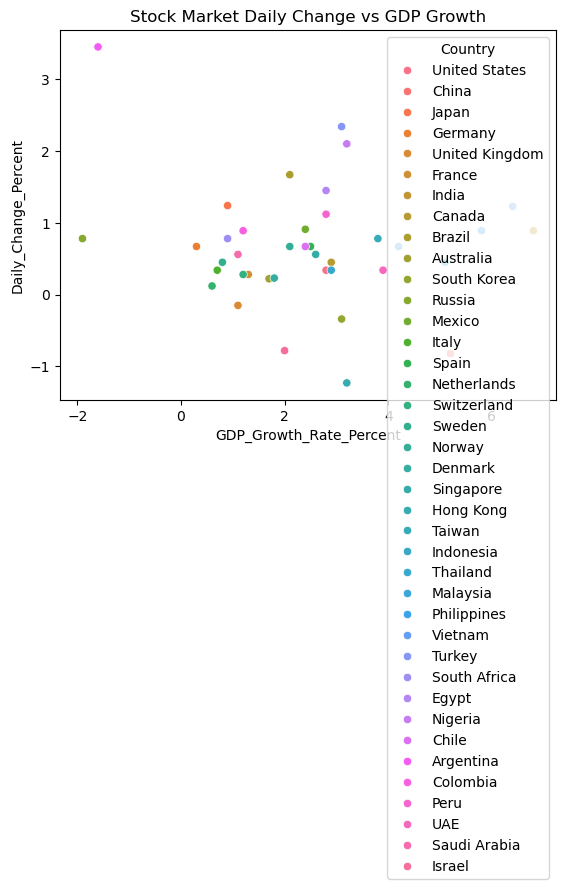

In [41]:
# Scatterplot for insights and to understand how macroeconomic indicators relate to stock market performance

#GDP vs Daily Change
sns.scatterplot(data=global_finance, x='GDP_Growth_Rate_Percent', y='Daily_Change_Percent', hue='Country')
plt.title("Stock Market Daily Change vs GDP Growth")
plt.show()

In [42]:
# To view the economic health Score by using multiple macro indicators
global_finance['Economic_Health_Score'] = (
    global_finance['GDP_Growth_Rate_Percent'] - global_finance['Inflation_Rate_Percent'] 
    + (10 - global_finance['Unemployment_Rate_Percent'])
    - global_finance['Government_Debt_GDP_Percent']/10
    - global_finance['Political_Risk_Score']
)

# View the top 5 healthiest economies
print(global_finance[['Country','Economic_Health_Score']].sort_values(by='Economic_Health_Score', ascending=False).head())

      Country  Economic_Health_Score
21  Hong Kong                   1.39
24   Thailand                  -1.94
36        UAE                  -2.45
22     Taiwan                  -2.97
23  Indonesia                  -3.58


In [43]:
# Country Clustering

# Select features for clustering
cluster_features = ['GDP_Growth_Rate_Percent','Inflation_Rate_Percent','Interest_Rate_Percent',
                    'Unemployment_Rate_Percent','Government_Debt_GDP_Percent','Daily_Change_Percent']
X = global_finance[cluster_features]

In [44]:
# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42)
global_finance['Cluster'] = kmeans.fit_predict(X_scaled)

C:\Users\omorb\anaconda3\Anaaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


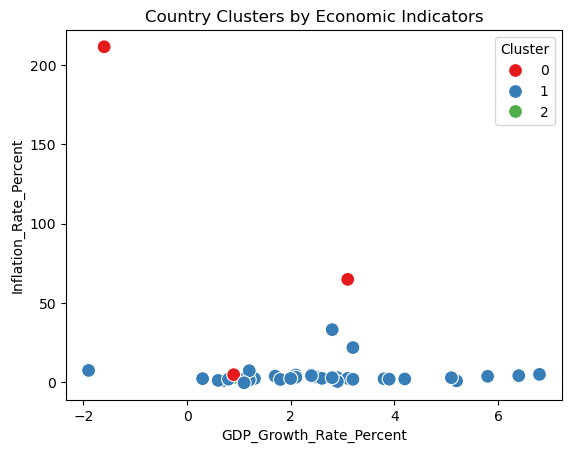

In [45]:
# Visualize clusters: GDP vs Inflation
sns.scatterplot(data=global_finance, x='GDP_Growth_Rate_Percent', y='Inflation_Rate_Percent', hue='Cluster', palette='Set1', s=100)
plt.title("Country Clusters by Economic Indicators")
plt.show()

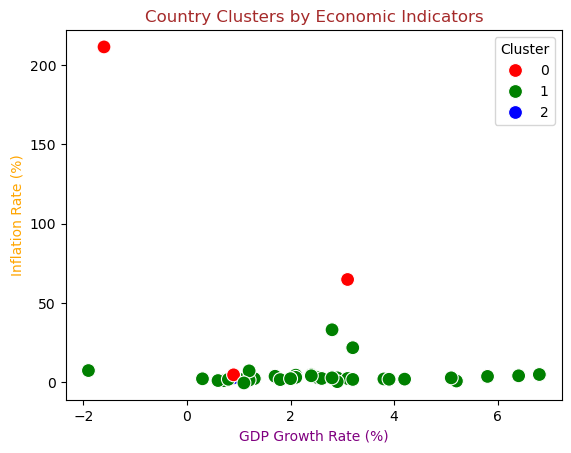

In [46]:
# # Visualize clusters: GDP vs Inflation
# Custom colors for clusters
palette_colors = {0: 'red', 1: 'green', 2: 'blue'}

# Visualize clusters: GDP vs Inflation
sns.scatterplot(
    data=global_finance,
    x='GDP_Growth_Rate_Percent',
    y='Inflation_Rate_Percent',
    hue='Cluster',
    palette=palette_colors,
    s=100
)

# Customize axis labels and title colors
plt.xlabel('GDP Growth Rate (%)', color='purple')
plt.ylabel('Inflation Rate (%)', color='orange')
plt.title("Country Clusters by Economic Indicators", color='brown')

plt.show()

In [47]:
# Predictive Modeling: Random Forest

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Features and target
features = ['GDP_Growth_Rate_Percent','Inflation_Rate_Percent','Interest_Rate_Percent',
            'Unemployment_Rate_Percent','Government_Debt_GDP_Percent','Exchange_Rate_USD']
target = 'Daily_Change_Percent'

X = global_finance[features]
y = global_finance[target]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predictions
y_pred = rf_model.predict(X_test)

# Evaluate model
print("R2 Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R2 Score: 0.5099889026929811
MSE: 0.5176722237500002


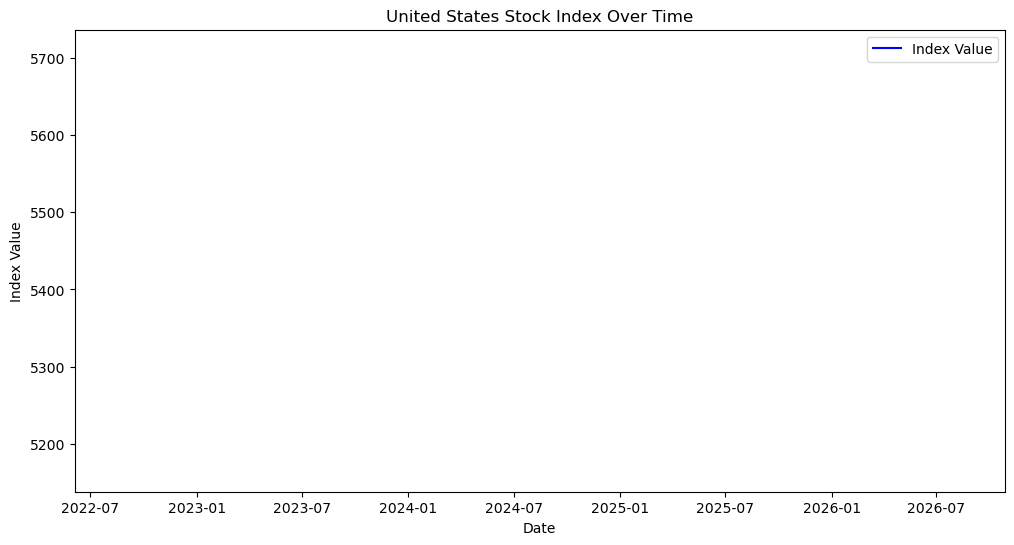

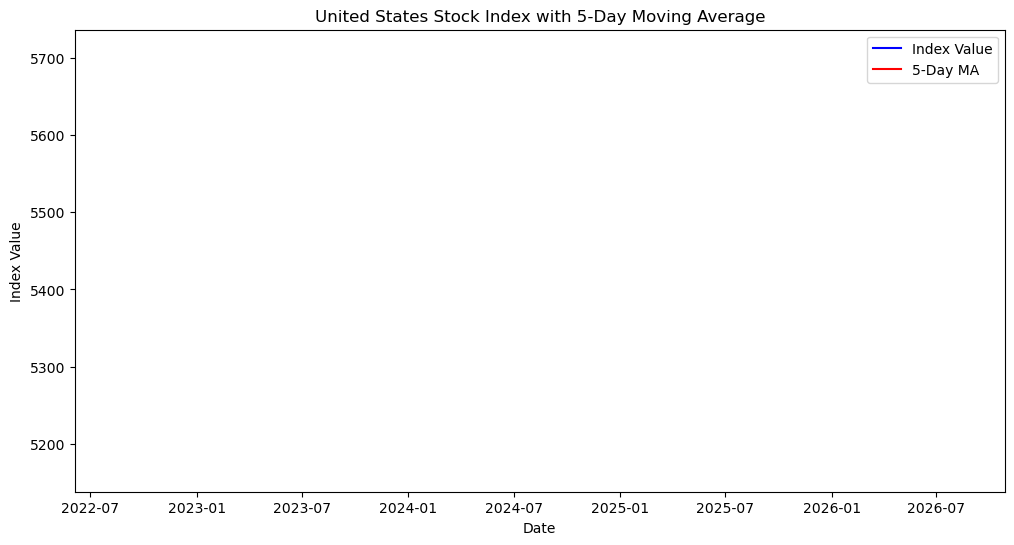

In [48]:
# Time series visualization for a specific country
country = 'United States'
df_country = global_finance[global_finance['Country'] == country]
df_country = df_country.sort_values('Date')

# Plot index value over time
plt.figure(figsize=(12,6))
plt.plot(df_country['Date'], df_country['Index_Value'], color='blue', label='Index Value')
plt.title(f"{country} Stock Index Over Time")
plt.xlabel("Date")
plt.ylabel("Index Value")
plt.legend()
plt.show()

# Moving average (5-day)
df_country['Index_MA5'] = df_country['Index_Value'].rolling(window=5).mean()
plt.figure(figsize=(12,6))
plt.plot(df_country['Date'], df_country['Index_Value'], color='blue', label='Index Value')
plt.plot(df_country['Date'], df_country['Index_MA5'], color='red', label='5-Day MA')
plt.title(f"{country} Stock Index with 5-Day Moving Average")
plt.xlabel("Date")
plt.ylabel("Index Value")
plt.legend()
plt.show()